# The KV cache: never compute the past twice

**The whole idea in one sentence:** in a causal model a token's key and value never
change once they've been computed, so keep them — and each new token then costs one
token of work instead of redoing the whole sequence.

[full_attention.ipynb](../mixers/full_attention.ipynb) met the cache briefly, as the
reason grouped-query attention exists. This notebook is about the cache itself:
why it's *allowed*, how to build one, what it costs, and the ways it goes wrong
without telling you.

By the end you'll have:

- generated text the wasteful way and counted the work: 500,500 token-passes to
  write 1,000 tokens
- **proved the cache is legal** — printed the past's keys before and after a new
  token arrives, and found them unchanged — then broken causality and watched the
  proof fail, which is why BERT-style models can't do this
- built a cache by hand and checked it against the full pass
- drawn the three shapes the attention mask takes, and used the wrong one: **a
  decoded token that can see only the first word of the prompt, and says nothing**
- decoded with RoPE and forgotten to say where the token is
- built the obvious cache with `torch.cat` and measured it copying gigabytes
- worked out what a cache costs in memory, and the context length at which it
  outweighs the model itself
- found out what a cache does **not** speed up

In [1]:
import math
import time

import numpy as np
import torch

torch.manual_seed(0)
np.set_printoptions(precision=3, suppress=True, linewidth=110)
torch.set_printoptions(precision=3, sci_mode=False, linewidth=110)

try:
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib not installed - plot cells will print a note instead (uv sync --extra demo)")

SURFACE, INK, INK2, GRID = "#fcfcfb", "#1f1e1d", "#6b6a63", "#e8e7e3"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

def style(ax):
    ax.set_facecolor(SURFACE); ax.set_axisbelow(True)
    ax.grid(color=GRID, lw=0.6)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values():
        s.set_visible(False)

---
## 1. Generating the wasteful way

A language model turns a sequence into a prediction for the next token. To write
text you call it in a loop: predict, append, predict again.

Here is a small causal model built from nothing but four matrices per layer — two
layers of attention with a residual connection, no MLP, no positions. Enough to
generate with, small enough to see through.

In [2]:
D, LAYERS = 64, 2
g = torch.Generator().manual_seed(0)
W = [{name: torch.randn(D, D, generator=g) / math.sqrt(D) for name in "qkvo"} for _ in range(LAYERS)]

def attend(q, k, v, allowed):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    return scores.masked_fill(~allowed, float("-inf")).softmax(-1) @ v

def layer_full(x, w, causal=True):
    # the whole sequence at once: what training does
    n = x.shape[0]
    q, k, v = x @ w["q"].T, x @ w["k"].T, x @ w["v"].T
    allowed = torch.ones(n, n, dtype=torch.bool)
    if causal:
        allowed = allowed.tril()
    return x + attend(q, k, v, allowed) @ w["o"].T, k, v

def model_full(x, causal=True):
    keys = []
    for w in W:
        x, k, _ = layer_full(x, w, causal)
        keys.append(k)
    return x, keys

tokens = torch.randn(8, D, generator=g)             # stand-ins for eight token embeddings
out, _ = model_full(tokens)
print("in", tuple(tokens.shape), "-> out", tuple(out.shape), "  only the last row predicts the next token")

in (8, 64) -> out (8, 64)   only the last row predicts the next token


To generate, run the model on everything so far, read the **last** row, pick a token,
append it, and go again. Count the work as "tokens pushed through the model":

In [3]:
def work_without_a_cache(n_new, prompt=1):
    return sum(prompt + step for step in range(n_new))      # step t reprocesses all t tokens so far

print("tokens to write   token-passes through the model   per token written")
for n in (10, 100, 1000, 10_000):
    total = work_without_a_cache(n)
    print(f"{n:>15,}   {total:>28,}   {total / n:>17,.1f}")

tokens to write   token-passes through the model   per token written
             10                             55                 5.5
            100                          5,050                50.5
          1,000                        500,500               500.5
         10,000                     50,005,000             5,000.5


Writing 1,000 tokens pushes half a million tokens through the model. Every step redoes
everything the step before it did, plus one. The cost per token grows with the
length of the text, so the total grows with its **square**.

And almost all of it is recomputing numbers that were already computed.

---
## 2. Why the past can be kept

Here's the claim the whole technique rests on: **when a new token arrives, nothing
about the earlier tokens changes.** Not their keys, not their values, in any layer.

Don't take it on trust. Run the model on five tokens, then on six, and compare what
it computed for the first five:

In [4]:
def compare_past(causal):
    _, keys_5 = model_full(tokens[:5], causal)
    _, keys_6 = model_full(tokens[:6], causal)          # one more token arrives
    return [(keys_6[layer][:5] - keys_5[layer]).abs().max().item() for layer in range(LAYERS)]

print("how much did the first five tokens' keys move when a sixth arrived?\n")
for label, causal in (("causal (GPT-style)", True), ("bidirectional (BERT-style)", False)):
    moved = compare_past(causal)
    print(f"  {label:28} layer 0: {moved[0]:.6f}    layer 1: {moved[1]:.6f}")

how much did the first five tokens' keys move when a sixth arrived?

  causal (GPT-style)           layer 0: 0.000000    layer 1: 0.000000
  bidirectional (BERT-style)   layer 0: 0.000000    layer 1: 1.145040


**Causal: nothing moved, in either layer.** Layer 0's keys are a projection of each
token's own embedding, so of course a new token can't touch them. Layer 1's keys are
a projection of layer 0's *output* — and under a causal mask, token 3's output is
built only from tokens 0–3. Token 5 showing up can't reach it. By induction that holds
at every depth.

**Bidirectional: layer 1 moved a lot.** Without the mask, token 3 attends to token 5,
so its layer-0 output changes the moment token 5 exists, and so does everything
computed from it. There's nothing stable to keep. That's why a KV cache is a feature
of *decoders*, and why an encoder like BERT has to rerun the whole sequence.

**That's the entire trick.** The causal mask was introduced so training couldn't cheat.
As a side effect it makes every token's history immutable — and immutable things can
be cached.

What people expect, and it isn't so: that the cache is an approximation, trading a
little accuracy for speed. It isn't. It stores exactly the numbers that would have been
recomputed. The output is the same output.

---
## 3. Building one

Keep each layer's keys and values. When a new token arrives, compute **its** query,
key and value, append the key and value, and attend the one query over everything
kept.

In [5]:
def layer_step(x_new, w, cache):
    # x_new is ONE token, [1, D]. Everything about the past comes from the cache.
    q, k, v = x_new @ w["q"].T, x_new @ w["k"].T, x_new @ w["v"].T
    cache["k"] = torch.cat((cache["k"], k))             # section 6 is about this line
    cache["v"] = torch.cat((cache["v"], v))
    everything = torch.ones(1, cache["k"].shape[0], dtype=torch.bool)   # all of it is the past
    return x_new + attend(q, cache["k"], cache["v"], everything) @ w["o"].T

def model_step(x_new, caches):
    for w, cache in zip(W, caches):
        x_new = layer_step(x_new, w, cache)
    return x_new

caches = [{"k": torch.empty(0, D), "v": torch.empty(0, D)} for _ in range(LAYERS)]
stepwise = torch.cat([model_step(tokens[t : t + 1], caches) for t in range(8)])
at_once, _ = model_full(tokens)

print("eight single-token steps with a cache == one pass over all eight:",
      torch.allclose(stepwise, at_once, atol=1e-5))
print("largest difference:", f"{(stepwise - at_once).abs().max().item():.1e}")

eight single-token steps with a cache == one pass over all eight: True
largest difference: 1.7e-06


Same numbers, to within floating-point rounding (the two routes multiply
different-shaped matrices, and float addition isn't associative, so the last bit can
differ).

Two things to notice in `layer_step`.

**There's no causal mask.** The mask exists to hide the future, and during decoding
there is no future — the cache holds only what came before. Every entry is allowed.

**Queries aren't cached.** A query is the question a token asks, and it's asked once, by
that token, at the moment it's produced. Nobody ever needs token 3's query again. Its
key and value, though, get read by every token that comes after. That asymmetry is
why it's a *KV* cache, and why grouped-query attention shrinks it by sharing keys and
values while keeping every query head.

The work is now one token per step:

In [6]:
print("tokens to write   without a cache   with a cache   saving")
for n in (10, 100, 1000, 10_000):
    a = work_without_a_cache(n)
    print(f"{n:>15,}   {a:>15,}   {n:>12,}   {a / n:>6,.0f}x")

tokens to write   without a cache   with a cache   saving
             10                55             10        6x
            100             5,050            100       50x
          1,000           500,500          1,000      500x
         10,000        50,005,000         10,000    5,000x


---
## 4. The three shapes of the mask

In practice generation isn't *only* single-token steps. It starts with a **prefill**:
the whole prompt goes through in one parallel pass, filling the cache. Then come the
single-token **decode** steps. And sometimes a chunk of several tokens gets appended
to a cache that already holds something — a long prompt processed in pieces, or a new
user message in a running conversation.

So the question "which keys may query `i` see?" has one answer with three faces. Query
`i` sits at absolute position `past + i`, and may see key `j` whenever `j <= past + i`:

In [7]:
def mask(past, new):
    return torch.ones(new, past + new, dtype=torch.bool).tril(diagonal=past)

print("prefill: nothing cached, 5 new tokens\n", mask(0, 5).int(), "\n")
print("decode: 5 cached, 1 new token\n", mask(5, 1).int(), "\n")
print("chunk: 3 cached, 3 new tokens\n", mask(3, 3).int())

prefill: nothing cached, 5 new tokens
 tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32) 

decode: 5 cached, 1 new token
 tensor([[1, 1, 1, 1, 1, 1]], dtype=torch.int32) 

chunk: 3 cached, 3 new tokens
 tensor([[1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)


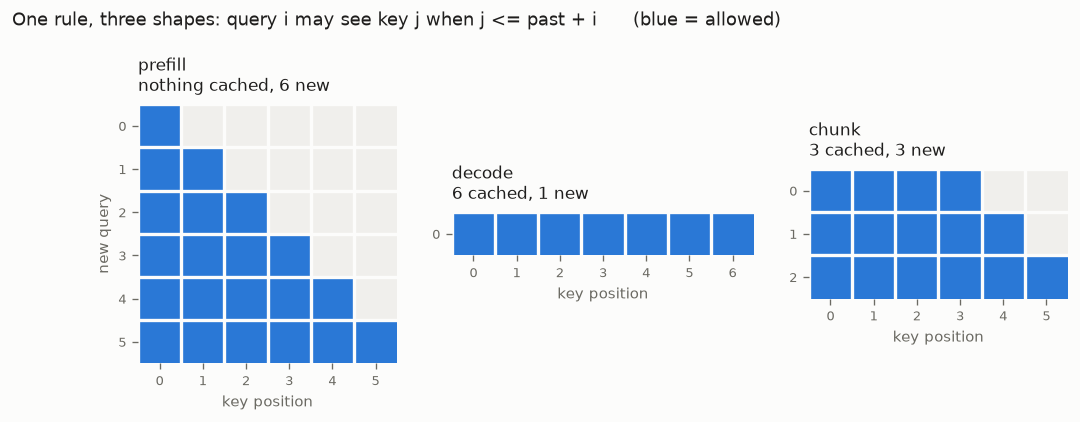

In [8]:
if HAVE_MPL:
    cmap = ListedColormap(["#f0efec", BLUE])
    cases = [("prefill\nnothing cached, 6 new", mask(0, 6)),
             ("decode\n6 cached, 1 new", mask(6, 1)),
             ("chunk\n3 cached, 3 new", mask(3, 3))]
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), dpi=120, gridspec_kw={"width_ratios": [6, 7, 6]})
    fig.patch.set_facecolor(SURFACE)
    for ax, (title, m) in zip(axes, cases):
        ax.set_facecolor(SURFACE)
        ax.imshow(m.int().numpy(), cmap=cmap, vmin=0, vmax=1, aspect="equal")
        rows, cols = m.shape
        ax.set_xticks(np.arange(cols) - 0.5, minor=True); ax.set_yticks(np.arange(rows) - 0.5, minor=True)
        ax.grid(which="minor", color=SURFACE, lw=2); ax.tick_params(which="minor", length=0)
        ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
        ax.tick_params(colors=INK2, labelsize=8)
        for s in ax.spines.values():
            s.set_visible(False)
        ax.set_title(title, color=INK, fontsize=10, loc="left", pad=8)
        ax.set_xlabel("key position", color=INK2, fontsize=9)
    axes[0].set_ylabel("new query", color=INK2, fontsize=9)
    fig.suptitle("One rule, three shapes: query i may see key j when j <= past + i      (blue = allowed)",
                 color=INK, fontsize=11, x=0.02, ha="left", y=1.04)
    plt.show()
else:
    print("(plot skipped)")

The square is training. The single row is decoding. The third — a triangle **shifted
right** by the length of the past — is the one that gets forgotten, because code is
usually written for the first two and tested on the first two.

### Break it on purpose: the token that can only see the first word

Fused attention kernels offer a convenient flag, `is_causal=True`, meaning "apply a
lower-triangular mask". It's what you use in training. Leave it on while decoding and
here's the mask it builds for one new token against six cached ones:

In [9]:
wrong = torch.ones(1, 7, dtype=torch.bool).tril()        # "lower triangle", aligned to the top-left
right = mask(6, 1)
print("what is_causal builds:", wrong.int().tolist()[0])
print("what it should be    :", right.int().tolist()[0])

q = torch.randn(1, D, generator=g)
k = torch.randn(7, D, generator=g)
scores = q @ k.T / math.sqrt(D)
for name, m in (("wrong", wrong), ("right", right)):
    weights = scores.masked_fill(~m, float("-inf")).softmax(-1)
    print(f"\nattention weights, {name} mask:", [round(x, 2) for x in weights[0].tolist()])

what is_causal builds: [1, 0, 0, 0, 0, 0, 0]
what it should be    : [1, 1, 1, 1, 1, 1, 1]

attention weights, wrong mask: [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

attention weights, right mask: [0.03, 0.44, 0.12, 0.14, 0.12, 0.12, 0.03]


"Lower triangle" is defined from the **top-left corner**. For a square that's exactly
causal masking. For a single row it keeps one entry: the first key. So the new token
attends with weight 1.0 to the first word of the prompt and ignores everything else —
including the token right before it.

That's a perfectly valid probability distribution. Nothing raises. The model produces
fluent-looking text that has forgotten the conversation. It's the reason the repo's
fast attention tier has three branches where you'd expect one: the flag for an empty
cache, **no mask at all** for a single token, and an explicit shifted triangle for a
chunk.

---
## 5. Break it on purpose: a token that doesn't know where it is

Add positions. With RoPE, a query and key are each turned by their absolute position
before they're compared ([rope.ipynb](../positional/rope.ipynb)). During training
that's free: position `i` is just row `i`. During decoding the new token arrives
**alone**, as row 0 of a one-row tensor — and it is *not* at position 0.

In [10]:
def rope(x, positions, base=10000.0):
    speeds = base ** (-torch.arange(0, x.shape[-1], 2, dtype=torch.float32) / x.shape[-1])
    angle = positions[:, None].float() * speeds
    a, b = x.chunk(2, dim=-1)
    return torch.cat((a * angle.cos() - b * angle.sin(), a * angle.sin() + b * angle.cos()), dim=-1)

w = W[0]
n = 12
seq = torch.randn(n, D, generator=g)
pos = torch.arange(n)

# the truth: the whole sequence at once
q_all, k_all = rope(seq @ w["q"].T, pos), rope(seq @ w["k"].T, pos)
truth = (q_all[-1:] @ k_all.T / math.sqrt(D)).softmax(-1)

# decoding the last token against cached, already-rotated keys
cached_keys = k_all                                         # rotated once, when each token arrived
q_new = seq[-1:] @ w["q"].T
correct = (rope(q_new, torch.tensor([n - 1])) @ cached_keys.T / math.sqrt(D)).softmax(-1)
forgot = (rope(q_new, torch.tensor([0])) @ cached_keys.T / math.sqrt(D)).softmax(-1)    # "it's row 0"

show = lambda t: [round(x, 2) for x in t[0].tolist()]
print("full pass        :", show(truth))
print("decode, position 11:", show(correct))
print("decode, position 0 :", show(forgot))
print(f"\ncorrect matches the full pass: {torch.allclose(truth, correct, atol=1e-5)}     "
      f"forgot matches: {torch.allclose(truth, forgot, atol=1e-5)}")

full pass        : [0.05, 0.02, 0.01, 0.01, 0.17, 0.07, 0.05, 0.37, 0.02, 0.02, 0.03, 0.17]
decode, position 11: [0.05, 0.02, 0.01, 0.01, 0.17, 0.07, 0.05, 0.37, 0.02, 0.02, 0.03, 0.17]
decode, position 0 : [0.04, 0.01, 0.02, 0.01, 0.2, 0.03, 0.04, 0.26, 0.04, 0.01, 0.14, 0.22]

correct matches the full pass: True     forgot matches: False


Same query content, same cached keys, a different attention pattern — because the
query was turned as though it opened the document. RoPE's whole property is that the
score depends on the *distance* between two positions, and we just told it the
distance was negative.

Again: nothing raises, and the weights sum to one.

Two design consequences, both visible in the repo. The cache stores keys **already
rotated**: a token's position is fixed the moment it exists, so the rotation happens
once on the way in. And for a full-attention cache, the next token's position *is* the
number of tokens already cached — so the mixer can check that the `pos_offset` it was
handed matches, and refuses when it doesn't.

---
## 6. Break it on purpose: the cache that copies everything

Look again at section 3's cache: `torch.cat((cache["k"], k))`. `cat` can't extend a
tensor in place. It allocates a new one and **copies the entire history into it**,
every step. We removed the quadratic *compute* and put back a quadratic amount of
*memory traffic*.

The fix is to allocate the space once and write each token into the next free slot:

In [11]:
def fill_with_cat(n, width):
    cache = torch.empty(0, width)
    copied = 0
    for _ in range(n):
        copied += cache.numel() * 4                       # bytes moved: the whole history, again
        cache = torch.cat((cache, torch.zeros(1, width)))
    return cache, copied

def fill_preallocated(n, width):
    cache, length = torch.zeros(n, width), 0              # allocate once
    for _ in range(n):
        cache[length] = 0.0                               # write one row
        length += 1
    view = cache[:length]                                 # a view: no copy
    return view, n * width * 4

n, width = 4000, 1024
for name, fn in (("torch.cat each step", fill_with_cat), ("preallocated", fill_preallocated)):
    t0 = time.perf_counter()
    _, copied = fn(n, width)
    print(f"{name:22} {time.perf_counter() - t0:6.2f}s   bytes moved: {copied / 1e9:6.2f} GB")

torch.cat each step      1.00s   bytes moved:  32.76 GB
preallocated             0.00s   bytes moved:   0.02 GB


Same result, thousands of times less data moved. This one isn't *silent* — it's just
slow — but it's slow in a way that's easy to blame on the model.

A preallocated cache needs to know its maximum length up front, and has to decide what
happens when it's full. For full attention there's only one honest answer: **raise.**
Quietly dropping the oldest token would change what every later token attends to. (A
cache that drops old tokens *on purpose* is a different mixer — sliding-window
attention — and it's the next one on the roadmap.)

---
## 7. What it costs

The cache trades compute for memory, and the memory isn't small. Per token of context:

```
bytes = 2 (a key and a value) x layers x kv_heads x head_dim x bytes per number
```

It grows with **context length** and with **batch size**, and unlike the weights,
every sequence being generated needs its own.

In [12]:
def bytes_per_token(layers, kv_heads, head_dim, bytes_per=2):
    return 2 * layers * kv_heads * head_dim * bytes_per

MODELS = [
    # name,                        layers, kv_heads, head_dim, bytes, weights (GB)
    ("this repo's 17M (fp32)",          6,        2,       32,     4,   0.07),
    ("GPT-2 small, 124M",              12,       12,       64,     2,   0.25),
    ("Llama-2 7B (multi-head)",        32,       32,      128,     2,   13.5),
    ("Llama-2 70B (8 KV heads)",       80,        8,      128,     2,  138.0),
    ("...70B if it were multi-head",   80,       64,      128,     2,  138.0),
]

def size(n):
    return f"{n / 1e9:,.1f} GB" if n >= 1e9 else f"{n / 1e6:,.1f} MB"

print(f"{'model':30} {'per token':>10}  {'4k context':>11} {'32k':>10} {'128k':>10}   outweighs the model at")
for name, layers, kv, hd, b, weights in MODELS:
    per = bytes_per_token(layers, kv, hd, b)
    crossover = weights * 1e9 / per
    print(f"{name:30} {per / 1e3:>7,.1f} kB  {size(per * 4096):>11} {size(per * 32_768):>10} "
          f"{size(per * 131_072):>10}   {crossover:>10,.0f} tokens")

model                           per token   4k context        32k       128k   outweighs the model at
this repo's 17M (fp32)             3.1 kB      12.6 MB   100.7 MB   402.7 MB       22,786 tokens
GPT-2 small, 124M                 36.9 kB     151.0 MB     1.2 GB     4.8 GB        6,782 tokens
Llama-2 7B (multi-head)          524.3 kB       2.1 GB    17.2 GB    68.7 GB       25,749 tokens
Llama-2 70B (8 KV heads)         327.7 kB       1.3 GB    10.7 GB    42.9 GB      421,143 tokens
...70B if it were multi-head   2,621.4 kB      10.7 GB    85.9 GB   343.6 GB       52,643 tokens


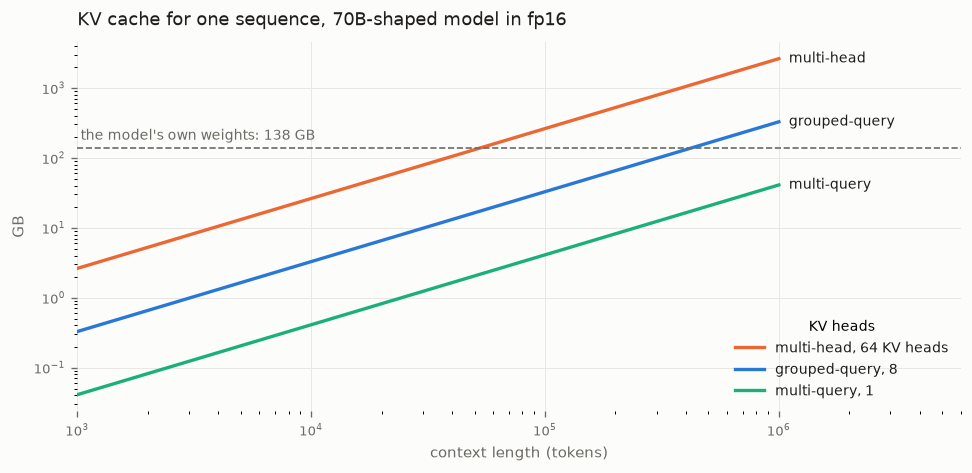

In [13]:
if HAVE_MPL:
    context = np.logspace(3, 6, 60)
    fig, ax = plt.subplots(figsize=(9.5, 4), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax)
    for (label, kv), color in zip((("multi-head, 64 KV heads", 64), ("grouped-query, 8", 8), ("multi-query, 1", 1)),
                                  (ORANGE, BLUE, AQUA)):
        gb = bytes_per_token(80, kv, 128) * context / 1e9
        ax.plot(context, gb, color=color, lw=2, label=label)
        ax.annotate(label.split(",")[0], (context[-1], gb[-1]), xytext=(6, 0), textcoords="offset points",
                    color=INK, fontsize=8.5, va="center")
    ax.axhline(138, color=INK2, lw=1, ls="--")
    ax.annotate("the model's own weights: 138 GB", (1e3, 138), xytext=(2, 5), textcoords="offset points",
                color=INK2, fontsize=8.5)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(1e3, 6e6)
    ax.set_title("KV cache for one sequence, 70B-shaped model in fp16", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("context length (tokens)", color=INK2, fontsize=9)
    ax.set_ylabel("GB", color=INK2, fontsize=9)
    ax.legend(loc="lower right", fontsize=8.5, frameon=False, labelcolor=INK, title="KV heads", title_fontsize=8.5)
    plt.show()
else:
    print("(plot skipped)")

A 70B model with plain multi-head attention would see its cache outweigh its own
weights at around 53,000 tokens — for **one** sequence. Serve eight users at once and
it's eight caches. Grouped-query attention, by keeping 8 KV heads instead of 64,
pushes that crossover out eightfold.

This is the pressure behind most of what this repo is for. Sliding-window attention
caps the cache at a fixed window. Multi-head latent attention stores a compressed
vector instead of full keys and values. Linear attention has **no cache at all** —
its state is a fixed-size matrix that doesn't grow with context. Each of them is a
different answer to the table above.

---
## 8. What it's worth — and what it doesn't fix

Measure it. Four layers, width 256, one token at a time up to 300:

In [14]:
D2, L2, N = 256, 4, 300
g2 = torch.Generator().manual_seed(1)
W2 = [{name: torch.randn(D2, D2, generator=g2) / math.sqrt(D2) for name in "qkvo"} for _ in range(L2)]
xs = torch.randn(N, D2, generator=g2)

def full_last(x):                                           # no cache: rerun everything, keep the last row
    for w in W2:
        n = x.shape[0]
        q, k, v = x @ w["q"].T, x @ w["k"].T, x @ w["v"].T
        x = x + attend(q, k, v, torch.ones(n, n, dtype=torch.bool).tril()) @ w["o"].T
    return x[-1:]

class Prealloc:
    def __init__(self):
        self.k, self.v, self.n = torch.zeros(N, D2), torch.zeros(N, D2), 0
    def append(self, k, v):
        self.k[self.n], self.v[self.n] = k[0], v[0]
        self.n += 1
        return self.k[: self.n], self.v[: self.n]

def step(x_new, caches):
    for w, c in zip(W2, caches):
        k_all, v_all = c.append(x_new @ w["k"].T, x_new @ w["v"].T)
        x_new = x_new + attend(x_new @ w["q"].T, k_all, v_all,
                               torch.ones(1, c.n, dtype=torch.bool)) @ w["o"].T
    return x_new

with torch.no_grad():
    slow, fast, caches = [], [], [Prealloc() for _ in range(L2)]
    for t in range(N):
        t0 = time.perf_counter(); a = full_last(xs[: t + 1]); slow.append(time.perf_counter() - t0)
        t0 = time.perf_counter(); b = step(xs[t : t + 1], caches); fast.append(time.perf_counter() - t0)
    assert torch.allclose(a, b, atol=1e-4)

print(f"time for the 300th token:  without a cache {np.mean(slow[-20:]) * 1e3:6.2f} ms   "
      f"with {np.mean(fast[-20:]) * 1e3:6.2f} ms   ({np.mean(slow[-20:]) / np.mean(fast[-20:]):.0f}x)")
print(f"time for all 300:          without a cache {sum(slow):6.2f} s    with {sum(fast):6.2f} s")

time for the 300th token:  without a cache   1.33 ms   with   0.11 ms   (12x)
time for all 300:          without a cache   0.22 s    with   0.03 s


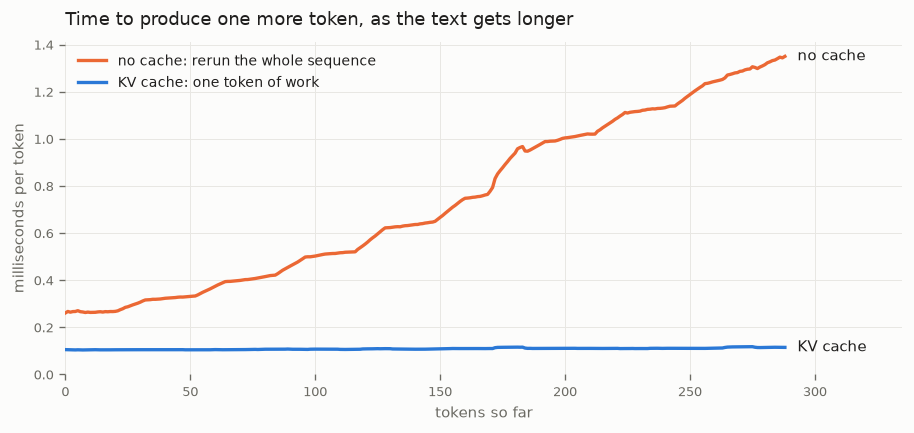

In [15]:
if HAVE_MPL:
    def smooth(v, n=12):
        return np.convolve(v, np.ones(n) / n, mode="valid") * 1e3
    fig, ax = plt.subplots(figsize=(9, 3.6), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax)
    ax.plot(smooth(slow), color=ORANGE, lw=2, label="no cache: rerun the whole sequence")
    ax.plot(smooth(fast), color=BLUE, lw=2, label="KV cache: one token of work")
    ax.annotate("no cache", (len(smooth(slow)), smooth(slow)[-1]), xytext=(6, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
    ax.annotate("KV cache", (len(smooth(fast)), smooth(fast)[-1]), xytext=(6, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
    ax.set_xlim(0, 335); ax.set_ylim(0, None)
    ax.set_title("Time to produce one more token, as the text gets longer", color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("tokens so far", color=INK2, fontsize=9); ax.set_ylabel("milliseconds per token", color=INK2, fontsize=9)
    ax.legend(loc="upper left", fontsize=8.5, frameon=False, labelcolor=INK)
    plt.show()
else:
    print("(plot skipped)")

Without a cache, each token costs more than the last. With one, the cost per token is
nearly flat — it still creeps up, because the one query is compared against an
ever-longer list of keys, but that's a single matrix-vector product instead of a full
forward pass over the history.

### What a cache does not fix

It's tempting to conclude the cache always makes generation faster. Here are numbers
from this repo's trained 17M-parameter TinyStories model, generating one sequence,
producing identical tokens either way:

| device | new tokens | no cache | KV cache | |
|---|---|---|---|---|
| CPU | 50 | 241 tok/s | 535 tok/s | 2.2x faster |
| CPU | 200 | 133 tok/s | 518 tok/s | 3.9x faster |
| Apple GPU | 50 | 103 tok/s | 63 tok/s | **1.6x slower** |
| Apple GPU | 200 | 96 tok/s | 138 tok/s | 1.4x faster |

On the GPU, for short generations, **the cache loses.** The reason is what a decode
step actually costs. Each step launches a few dozen small GPU kernels, and each launch
has a fixed overhead that doesn't depend on how much arithmetic it does. With a model
this small and a single sequence, a step is almost entirely that overhead. The
cache-free route does far more arithmetic — but in a few large, efficient operations.
The cache removed arithmetic, and arithmetic wasn't the bottleneck.

The general version of this is the most useful thing to know about inference:

- **Prefill is compute-bound.** Thousands of tokens in parallel; the GPU's arithmetic
  units are the limit.
- **Decode is memory-bound.** One token at a time, and for that one token the GPU must
  read *every weight* and *the entire cache* out of memory. The arithmetic is trivial;
  the reading is the cost.

That's why inference servers **batch** many users' decode steps together — the weights
get read once and used for everyone — and why shrinking the cache (section 7) matters
for speed and not only for fitting in memory: a smaller cache is less to read per token.

---
## 9. The packaged version

`litterbox.infer.KVCache` is section 6's preallocated buffer, with shape checks and
byte accounting. Nobody constructs one directly: generation **asks each mixer** for the
state it needs, so a layer with a KV cache and a layer with a fixed-size recurrent
matrix look the same from outside.

In [16]:
from litterbox.infer import generate, generate_uncached
from litterbox.model import dense_transformer

torch.manual_seed(0)
model = dense_transformer(vocab_size=500, d_model=128, n_layers=4, heads=8, kv_heads=2, max_seq_len=128).eval()

states = model.init_states(batch_size=1, max_len=64)         # one per block; each block answers for itself
print(len(states), "states.  the first:", states[0].kv)

prompt = torch.randint(0, 500, (1, 10))
with torch.no_grad():
    logits = model(prompt, states, pos_offset=0)             # prefill: fills every cache in one pass
    print("after a 10-token prefill:", states[0].kv)
    nxt = logits[:, -1].argmax(-1, keepdim=True)
    model(nxt, states, pos_offset=10)                        # decode: one token, at position 10
    print("after one decode step   :", states[0].kv)

4 states.  the first: <KVCache 0/64 tokens, batch=1, kv_heads=2, head_dim=16, torch.float32, 0.00 MB used of 0.02 MB>
after a 10-token prefill: <KVCache 10/64 tokens, batch=1, kv_heads=2, head_dim=16, torch.float32, 0.00 MB used of 0.02 MB>
after one decode step   : <KVCache 11/64 tokens, batch=1, kv_heads=2, head_dim=16, torch.float32, 0.00 MB used of 0.02 MB>


The cache is sized by **KV heads** — 2 here, not the 8 query heads — which is grouped-query
attention's saving, realised. And the traps from sections 4 and 5 are refused rather than
allowed to pass quietly:

In [17]:
def attempt(label, fn):
    try:
        with torch.no_grad():
            fn()
        print(f"{label}: no error")
    except ValueError as e:
        print(f"{label}:\n   {e}\n")

more = torch.randint(0, 500, (1, 1))
attempt("decode without saying where the token is", lambda: model(more, states))
attempt("write past the end of the cache", lambda: model(torch.randint(0, 500, (1, 60)), states, pos_offset=11))
attempt("ask for more text than the context holds",
        lambda: generate(model, prompt, 200, max_context=128, temperature=0))

decode without saying where the token is:
   pos_offset=0 but the cache already holds 11 tokens. They must match: the next token's position is the number of tokens before it.

write past the end of the cache:
   cache is full: 11 stored + 60 new > max_len=64

ask for more text than the context holds:
   prompt (10) + max_new_tokens (200) = 210 exceeds max_context=128. A KV cache cannot slide: its keys were rotated at absolute positions. Shorten the request, or use generate_uncached.



That last one is worth a sentence. The cache-free generator can run forever: when the
text outgrows the context it drops the oldest tokens and carries on. A cache can't.
Its keys were rotated at absolute positions, so sliding the window would mean
re-rotating every key it holds.

And the claim that makes all of this safe — the step the roadmap wouldn't move past
without:

In [18]:
cached = generate(model, prompt, 100, max_context=128, temperature=0)
oracle = generate_uncached(model, prompt, 100, max_context=128, temperature=0)
print("greedy, 100 tokens - cached == cache-free:", torch.equal(cached, oracle))

g1, g2 = torch.Generator().manual_seed(7), torch.Generator().manual_seed(7)
a = generate(model, prompt, 100, max_context=128, temperature=0.9, top_k=40, generator=g1)
b = generate_uncached(model, prompt, 100, max_context=128, temperature=0.9, top_k=40, generator=g2)
print("sampled, same seed - cached == cache-free:", torch.equal(a, b))

greedy, 100 tokens - cached == cache-free: True


sampled, same seed - cached == cache-free: True


`generate_uncached` is the training-time forward pass in a loop. It can't be subtly
wrong, which makes it the oracle. `generate` has to produce the same tokens, and
`tests/test_generation.py` holds it to that across multi-head, grouped-query and
multi-query attention, both attention tiers, and learned or sinusoidal positions.

---
## 10. The real thing

If you've trained the TinyStories model (`python examples/train_tinystories.py`), this
loads the checkpoint and writes a story from its cache. If not, it says so and moves on.

In [19]:
from pathlib import Path

def find_checkpoint():
    here = Path.cwd().resolve()
    for root in (here, *here.parents):
        if (root / "runs").is_dir():
            found = sorted((root / "runs").glob("*/latest.pt"), key=lambda p: p.stat().st_mtime)
            if found:
                return found[-1]
    return None

ckpt = find_checkpoint()
story_model = None
if ckpt is None:
    print("no checkpoint under runs/. To train one:\n\n    python examples/train_tinystories.py\n")
else:
    try:
        from litterbox.data.tokenizer import build_tokenizer
        from litterbox.train import load_checkpoint
        tok = build_tokenizer({"type": "tiktoken", "encoding": "gpt2"})
        story_model = dense_transformer(50_304, 256, 6, 8, 2, max_seq_len=256)      # the script's default shape
        step = load_checkpoint(ckpt, story_model)
        story_model.eval()
        print(f"loaded {ckpt.parent.name}, trained for {step:,} steps")
    except Exception as e:                                # tiktoken missing, or a different shape
        story_model = None
        print(f"(skipped - {type(e).__name__}: {str(e)[:100]})")

loaded tinystories-verify, trained for 600 steps


In [20]:
if story_model is not None:
    prompt_ids = torch.tensor([tok.encode("Once upon a time, a little dragon")])
    gen = torch.Generator().manual_seed(3)
    out = generate(story_model, prompt_ids, 110, max_context=256, temperature=0.8, top_k=40,
                   eos_id=tok.eos_id, generator=gen)
    print(tok.decode(out[0].tolist()), "\n")

    for name, fn in (("cache-free", generate_uncached), ("KV cache", generate)):
        t0 = time.perf_counter()
        ids = fn(story_model, prompt_ids, 200, max_context=256, temperature=0)
        dt = time.perf_counter() - t0
        print(f"{name:11} 200 tokens in {dt:5.2f}s  ({200 / dt:5.0f} tok/s)")
    states = story_model.init_states(1, 256)
    print(f"\nthe whole cache, 6 layers at a full 256-token context: "
          f"{sum(s.kv.nbytes_allocated for s in states) / 1e6:.2f} MB")
else:
    print("(skipped: no trained checkpoint on this machine)")

Once upon a time, a little dragon came to the farm. He wanted to play with the rabbit.

One day, a girl named Sue wanted to play with the rabbit. Tim said, "No, I want to play with you!" So, Sue took the rabbit to the forest. They played together for a long time.

After a few minutes, the rabbit showed the rabbit a big, red balloon. The rabbit was sad, but she said, "You are a good friend, Tim." The rabbit said, "Thank you, little mouse. You are my 



cache-free  200 tokens in  1.49s  (  134 tok/s)


KV cache    200 tokens in  0.38s  (  533 tok/s)

the whole cache, 6 layers at a full 256-token context: 0.79 MB


---
## What to remember

| what | why |
|---|---|
| the cache is exact, not approximate | it stores the numbers that would have been recomputed |
| it's legal *because* of the causal mask | no later token can change an earlier token's key or value, at any depth |
| keys and values, never queries | a query is used once; keys and values are read by every later token |
| three mask shapes, one rule | `j <= past + i` — and a fused kernel's `is_causal` is only right for the square |
| rotate keys before caching; tell decode where it is | a lone token is row 0 of its tensor and *not* at position 0 |
| preallocate, and raise when full | `torch.cat` copies the whole history every step |
| memory grows with context **and** batch | which is what GQA, sliding windows, MLA and linear attention are each an answer to |
| it removes arithmetic, not latency | decode is memory-bound; for a small model on a GPU the cache can lose |

Two of the traps here — the top-left mask and the forgotten position — produce valid
probability distributions and fluent text. No shape check, NaN check or loss curve will
find them. The only test that does is the blunt one: **generate with the cache, generate
without it, and demand the same tokens.**

---

## Exercises

1. **Count the FLOPs.** For width `d` and context `n`, write the cost of one decode step
   with and without a cache, separating the projections (which scale with `d²`) from the
   attention itself (which scales with `n·d`). At what `n` does attention overtake the
   projections?
2. **Share a prefix.** Prefill a long prompt once, then continue it two different ways
   from two *copies* of the cache. Check both against `generate_uncached`. This is prefix
   caching, and it's why system prompts are cheap.
3. **A quantized cache.** Store the cache in int8 with one scale per token per head, and
   dequantize on read. How far do the logits move? How many tokens until greedy
   generation diverges from the fp32 cache?
4. **Ragged batches.** Two prompts of different lengths in one batch need padding — and a
   mask that hides it. Work out what the mask looks like for the prefill and for each
   decode step, and why left-padding is the usual choice.
5. **A cache that forgets on purpose.** Turn section 6's preallocated cache into a ring
   buffer holding only the last `w` tokens. What has to change about the mask? About the
   positions? What can the model no longer do? That's sliding-window attention, the next
   mixer on the roadmap.
6. **Make it real.** `TokenMixer.init_state()` is the seam that lets generation stay
   ignorant of what state is. Write `init_state` and the stateful `forward` for a mixer
   whose state does **not** grow: plain linear attention, where the state is a single
   `[heads, head_dim, head_dim]` matrix updated as `S += kᵀv`. `max_len` is ignored
   entirely. If `generate` works on it without a single change, the interface is real.